In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

import seaborn as sns

In [4]:
data = '..\\data\\course_lead_scoring_2026.csv'
df = pd.read_csv(data)
df.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


In [5]:
df.columns

Index(['lead_source', 'industry', 'employment_status', 'location',
       'annual_income', 'number_of_courses_viewed', 'interaction_count',
       'lead_score', 'converted'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               4852 non-null   str    
 1   industry                  4760 non-null   str    
 2   employment_status         4806 non-null   str    
 3   location                  4792 non-null   str    
 4   annual_income             4631 non-null   float64
 5   number_of_courses_viewed  5000 non-null   int64  
 6   interaction_count         5000 non-null   int64  
 7   lead_score                4965 non-null   float64
 8   converted                 5000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 351.7 KB


In [8]:
num_columns = df.select_dtypes(include=np.number).columns.tolist()
num_columns

['annual_income',
 'number_of_courses_viewed',
 'interaction_count',
 'lead_score',
 'converted']

In [9]:
cat_columns = df.select_dtypes(include='str').columns.tolist()
cat_columns

['lead_source', 'industry', 'employment_status', 'location']

In [10]:
def prepare_X(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # fillna for numerical columns
    for c in num_columns:
        df[c] = df[c].fillna(0)
    
    # fillna for categorical columns
    for c in cat_columns:
        df[c] = df[c].fillna('NA')
        
    return df

In [11]:
df_prepared = prepare_X(df)

## Q1

In [13]:
df_prepared['industry'].value_counts()

industry
technology       1173
retail            925
healthcare        840
finance           720
education         639
manufacturing     463
NA                240
Name: count, dtype: int64

## Q2

In [15]:
df_prepared[num_columns].corr()

,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
annual_income,1.000000,0.161300,0.122842,0.229496,0.189652
number_of_courses_viewed,0.161300,1.000000,0.721609,0.757204,0.395038
interaction_count,0.122842,0.721609,1.000000,0.915746,0.448624
lead_score,0.229496,0.757204,0.915746,1.000000,0.483246
converted,0.189652,0.395038,0.448624,0.483246,1.000000


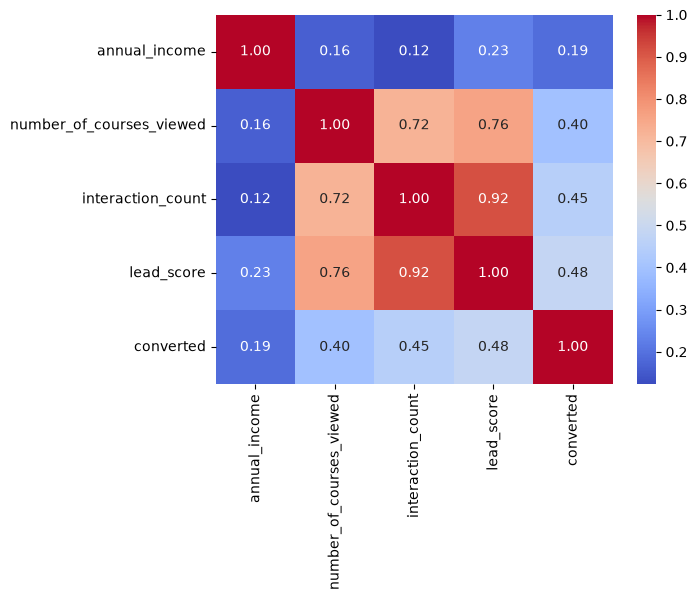

In [18]:
sns.heatmap(df_prepared[num_columns].corr(), annot=True, fmt=".2f", cmap="coolwarm");

## Split

In [19]:
df_full_train, df_test = train_test_split(df_prepared, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(
    df_full_train, test_size=0.25, random_state=42
)

y_train = df_train['converted'].values
y_val = df_val['converted'].values
y_test = df_test['converted'].values

df_train = df_train.drop(columns=['converted'])
df_val = df_val.drop(columns=['converted'])
df_test = df_test.drop(columns=['converted'])

## Q3

In [20]:
from sklearn.metrics import mutual_info_score

In [24]:
cat_columns = df_train.select_dtypes(include='str').columns.tolist()
num_columns = df_train.select_dtypes(include=np.number).columns.tolist()

In [27]:
for col in cat_columns:
    mi = mutual_info_score(y_train, df_train[col])
    print(f"{col}: {mi:.3f}")

lead_source: 0.034
industry: 0.002
employment_status: 0.019
location: 0.001


## Q4

In [28]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


In [38]:
pipe = Pipeline([
    ('dv', DictVectorizer(sparse=False)),
    ('model', LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42))
])


In [39]:
pipe.fit(df_train.to_dict(orient='records'), y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('dv', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"sparse sparse: bool, default=TrueWhether transform should produce scipy.sparse matrices.",False
,"dtype dtype: dtype, default=np.float64The type of feature values. Passed to Numpy array/scipy.sparse matrixconstructors as the dtype argument.",<class 'numpy.float64'>
,"separator separator: str, default=""=""Separator string used when constructing new features for one-hotcoding.",'='
,"sort sort: bool, default=TrueWhether ``feature_names_`` and ``vocabulary_`` should besorted when fitting.",True
Name,Type,Value


In [45]:
def model_valid(y_pred, y_val, factor=0.5):
    churn_decision = (y_pred >= factor)
    acc = (y_val == churn_decision).mean()
    return acc

In [40]:
y_pred = pipe.predict_proba(df_val.to_dict(orient='records'))[:, 1]

In [46]:
model_valid(y_pred, y_val, factor=0.5)

np.float64(0.645)

## Q5

In [49]:
pipe.fit(df_train.to_dict(orient='records'), y_train)
y_pred = pipe.predict_proba(df_val.to_dict(orient='records'))[:, 1]
original_accuracy = model_valid(y_pred, y_val, factor=0.5)

columns = df_train.columns.tolist()

for col in columns:
    df = df_train.copy()
    df.drop(columns=[col], inplace=True)

    pipe.fit(df.to_dict(orient='records'), y_train)
    y_pred = pipe.predict_proba(df_val.to_dict(orient='records'))[:, 1]
    acc = model_valid(y_pred, y_val, factor=0.5)
    diff = original_accuracy - acc

    print(f"Accuracy without {col}: {diff:.6f}")

Accuracy without lead_source: 0.003000
Accuracy without industry: 0.000000
Accuracy without employment_status: 0.000000
Accuracy without location: 0.000000
Accuracy without annual_income: -0.079000
Accuracy without number_of_courses_viewed: 0.002000
Accuracy without interaction_count: 0.044000
Accuracy without lead_score: 0.001000


## Q6

In [50]:
reg = [0.000001, 0.00001, 0.0001, 0.001]

for r in reg:
    pipe = Pipeline([
        ('dv', DictVectorizer(sparse=False)),
        ('model', LogisticRegression(solver='liblinear', C=r, max_iter=1000, random_state=42))
    ])
    
    pipe.fit(df_train.to_dict(orient='records'), y_train)
    y_pred = pipe.predict_proba(df_val.to_dict(orient='records'))[:, 1]
    acc = model_valid(y_pred, y_val, factor=0.5)
    
    print(f"Accuracy with regularization {r}: {acc:.6f}")

Accuracy with regularization 1e-06: 0.598000
Accuracy with regularization 1e-05: 0.598000
Accuracy with regularization 0.0001: 0.613000
Accuracy with regularization 0.001: 0.645000
